<h2> Parsing and Analyzing Marathon Runner Data </h2>

<img src="nyrr.png" style="float: right; width: 20%">


We are looking at marathon data from the New York City Marathon from the years 1985-2023. 

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("data.csv")

/var/folders/8r/dnd7f1s14_b2rpn5_dc2tgm80000gn/T/ipykernel_58075/649945830.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data.csv")


In [3]:
df.head()

,runnerId,firstName,lastName,bib,age,gender,city,countryCode,stateProvince,iaaf,overallPlace,overallTime,pace,genderPlace,ageGradeTime,ageGradePlace,ageGradePercent,racesCount,year
0,1264502,Orlando,Pizzolato,1,27,M,Vicenza,ITA,NaN,ITA,1,2:11:34,05:01,1.0,11:34,1.0,96.4,12,1985
1,1264503,Ahmed,Saleh,2,24,M,NaN,DJI,NaN,DJI,2,2:12:29,05:03,2.0,12:29,2.0,95.7,1,1985
2,1264504,Patrick,Petersen,21,25,M,Brooklyn,USA,NY,USA,3,2:12:59,05:04,3.0,12:59,3.0,95.3,12,1985
3,1264505,Don,Norman,19,27,M,Republic,USA,PA,USA,4,2:14:08,05:07,4.0,14:08,4.0,94.5,2,1985
4,1264506,Gerard,Nijboer,12,30,M,Uffelte,NED,NaN,NED,5,2:14:27,05:07,5.0,14:27,1.0,94.3,1,1985


In [5]:
df.tail()

,runnerId,firstName,lastName,bib,age,gender,city,countryCode,stateProvince,iaaf,overallPlace,overallTime,pace,genderPlace,ageGradeTime,ageGradePlace,ageGradePercent,racesCount,year
1311399,37990478,Donna,Zephrine,411.0,50,W,Bay Shore,USA,NY,USA,51344,10:38:42,24:22,22810.0,26:40,22808.0,23.90,5,2023
1311400,37981477,Ruth,Miller,11792.0,77,W,New York,USA,NY,USA,51345,10:40:55,24:27,22811.0,14:56,21395.0,36.12,316,2023
1311401,37981987,Honey,Lewis,12075.0,81,W,Los Angeles,USA,CA,USA,51346,10:50:48,24:50,22812.0,41:29,19727.0,39.66,26,2023
1311402,37982448,Michael,Rosengarten,409.0,72,M,West Palm Beach,USA,FL,USA,51347,11:42:19,26:48,28443.0,25:32,28439.0,24.32,128,2023
1311403,37981240,Bette,Clark,24795.0,68,W,Yonkers,USA,NY,CAN,51348,13:11:48,30:12,22813.0,04:50,22804.0,24.85,247,2023


The interesting columns in our dataset are

- Name
- Age
- Country
- gender
- overallPlace
- overallTime

Let's do some early disecting of the data. 

Let's first start by seeing how many runners per year.

In [13]:
Participant_Count = df['year'].value_counts().sort_index()

Text(0.5, 1.0, 'Participants in the NYC Marathon')

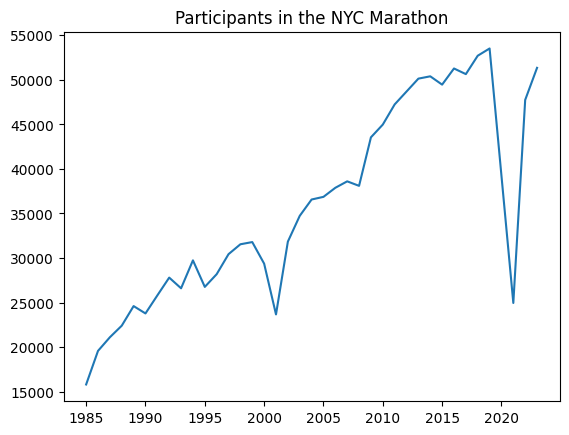

In [17]:
print(plt.plot(Participant_Count.index,Participant_Count.values))
plt.title("Participants in the NYC Marathon")

We can see that the number of participants in the annual NYC Marathon has been steadily increasing from about 15000 runners, up to 55000 with 2021 being an outlier year.

In [18]:
# Remove bad data
df = df[df['age']!=0]

Now let's look at how many runners under the age of 21 there are by year.

In [21]:
Under_21 = df[df['age']<=21]

Counts = Under_21.year.value_counts().sort_index()

Text(0.5, 1.0, 'Participants aged 21 or less in the NYC Marathon')

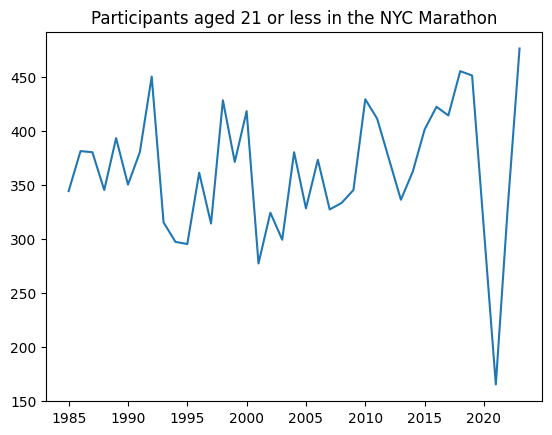

In [22]:
print(plt.plot(Counts.index,Counts.values))
plt.title("Participants aged 21 or less in the NYC Marathon")

There just aren't that many runners aged 21 or less participating in the Marathon, and this number hasn't increased over the years. Now let's look at the ages of the best place finishers.

In [23]:
df[df['overallPlace']==1]['age'].describe()

count    37.000000
mean     28.783784
std       3.180978
min      20.000000
25%      27.000000
50%      29.000000
75%      31.000000
max      36.000000
Name: age, dtype: float64

In [24]:
df[df['overallPlace']<=100]['age'].describe()

count    3694.000000
mean       31.690038
std         5.563023
min        18.000000
25%        28.000000
50%        31.000000
75%        35.000000
max        54.000000
Name: age, dtype: float64

The average age of the top finishers is `28.78` years old, and the average age of the top 100 runners is `31.69` years old.

There is a lot more we can do here, this is just the beginning of analysis on this dataset.